# Number of shots a team will take in an upcoming match

In [2]:
### Important libraries

from final_presentation import ShotPredictor
import pandas as pd

%load_ext autoreload
%autoreload 2

In [3]:
### Run this to call the class, might take a while to run, once run dont need to run again until you close the file

sp = ShotPredictor()

[PreparePastData] Dropped 2 rows with missing team or shot data.

[PreparePastData] 5 rows are missing odds:
      date home_team   away_team  league season
2020-10-18   Udinese       Parma serie_a   2021
2020-10-19    Verona       Genoa serie_a   2021
2022-01-10    Torino  Fiorentina serie_a   2122
2020-09-13  Paris SG   Marseille ligue_1   2021
2020-10-18    Monaco Montpellier ligue_1   2021

Use patch_odds() to manually supply odds for any of these.

[PreparePastData] Re-applied 4 manual patch(es) from manual_odds_patches.json.
  [Odds API] premier_league: 10 matches fetched
  [Odds API] bundesliga: 9 matches fetched
  [Odds API] la_liga: 13 matches fetched
  [Odds API] serie_a: 10 matches fetched
  [Odds API] ligue_1: 9 matches fetched


## Some notes

 
- It should not be a past date, it will only work for matches happening currently or matches which will happen in the future
- All the matches might not be available, the closer the match is to the current date, the more likely it is to be available.
- Matches early in the season are less likely to be available, as the data is updated after the match is played.
- Please be careful of the date format, it is in "YYYY-MM-DD" format
- The team names may not exactly match the team, for example West Ham United may be West Ham

In [19]:
date = '2026-05-15' # date of the match 
team = "Aston Villa"   #The team playing on the date

In [20]:
### Check all the matches happening on the date, and the teams playing in those matches 
### Useful to find the correct team name

sp.matches_on_date(date)

               date         league   home_team away_team
2026-05-15 20:00:00 premier_league Aston Villa Liverpool


,date,league,home_team,away_team
3,2026-05-15 20:00:00,premier_league,Aston Villa,Liverpool


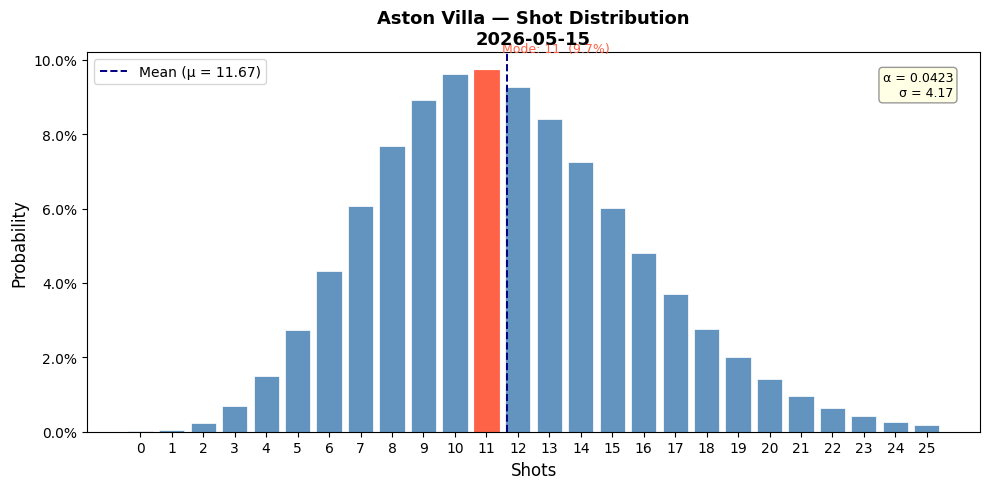

In [21]:
### Provides a graph to visualise the odds of the number of shots the team takes in the match

sp.plot(date, team)

- If you want to see the best bet for the match, you can use the following code
- The odds are in the format {number of shots: odds}, where the odds represents the payout if there are at least that many shots for the team in the match. Odds given by Betway in this format.
- The table displays if any of the given odds are underpriced based on the model.

In [22]:
odds = {9:1.15, 10:1.25, 11:1.42, 12:1.61, 13:1.9, 14:2.3, 15:2.75, 16:3.4, 17:4.2, 18:5.25, 19:6.5, 20:8, 21:9.0}


sp.betway_best_bet(date, team, odds)


  Aston Villa  |  2026-05-15
  μ = 11.67  |  α = 0.0423
threshold  odds  market_prob  model_prob    edge  half_kelly
       9+  1.15       0.8696      0.7641 -0.1054           0
      10+  1.25       0.8000      0.6749 -0.1251           0
      11+  1.42       0.7042      0.5787 -0.1255           0
      12+  1.61       0.6211      0.4815 -0.1396           0
      13+  1.90       0.5263      0.3887 -0.1376           0
      14+  2.30       0.4348      0.3047 -0.1301           0
      15+  2.75       0.3636      0.2321 -0.1316           0
      16+  3.40       0.2941      0.1718 -0.1223           0
      17+  4.20       0.2381      0.1237 -0.1144           0
      18+  5.25       0.1905      0.0867 -0.1038           0
      19+  6.50       0.1538      0.0590 -0.0948           0
      20+  8.00       0.1250      0.0390 -0.0860           0
      21+  9.00       0.1111      0.0249 -0.0862           0
  No positive EV found across all given odds — no bet recommended.



,threshold,odds,market_prob,model_prob,edge,half_kelly
0,9+,1.15,0.8696,0.7641,-0.1054,0
1,10+,1.25,0.8000,0.6749,-0.1251,0
2,11+,1.42,0.7042,0.5787,-0.1255,0
3,12+,1.61,0.6211,0.4815,-0.1396,0
4,13+,1.90,0.5263,0.3887,-0.1376,0
5,14+,2.30,0.4348,0.3047,-0.1301,0
6,15+,2.75,0.3636,0.2321,-0.1316,0
7,16+,3.40,0.2941,0.1718,-0.1223,0
8,17+,4.20,0.2381,0.1237,-0.1144,0
9,18+,5.25,0.1905,0.0867,-0.1038,0
